['CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'balance_log', 'salary_log', 'product_norm', 'tenure_norm', 'card_flag', 'active_flag', 'salary_balance_ratio', 'product_per_tenure', 'zero_balance_flag', 'high_balance_flag', 'Balance_Category', 'engagement_score', 'low_engagement_flag', 'activity_product_interaction', 'balance_activity_gap', 'tenure_engagement_ratio', 'is_dormant_high_value', 'product_intensity', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'cluster_id', 'dist_to_cluster_0', 'dist_to_cluster_1', 'dist_to_cluster_2', 'dist_to_cluster_3', 'dist_to_cluster_4', 'Engagement_Segment', 'is_active_power_core', 'is_active_casual', 'is_inactive_disengaged', 'is_inactive_high_balance', 'is_inactive_low_balance', 'customer_value_segment', 'Exited', 'Product_Segment', 'Product_Group', 'Product_Combination', 'Active_Product_Count', 'Product_Utilization_Ratio', 'Normalized_Engagement', 'P

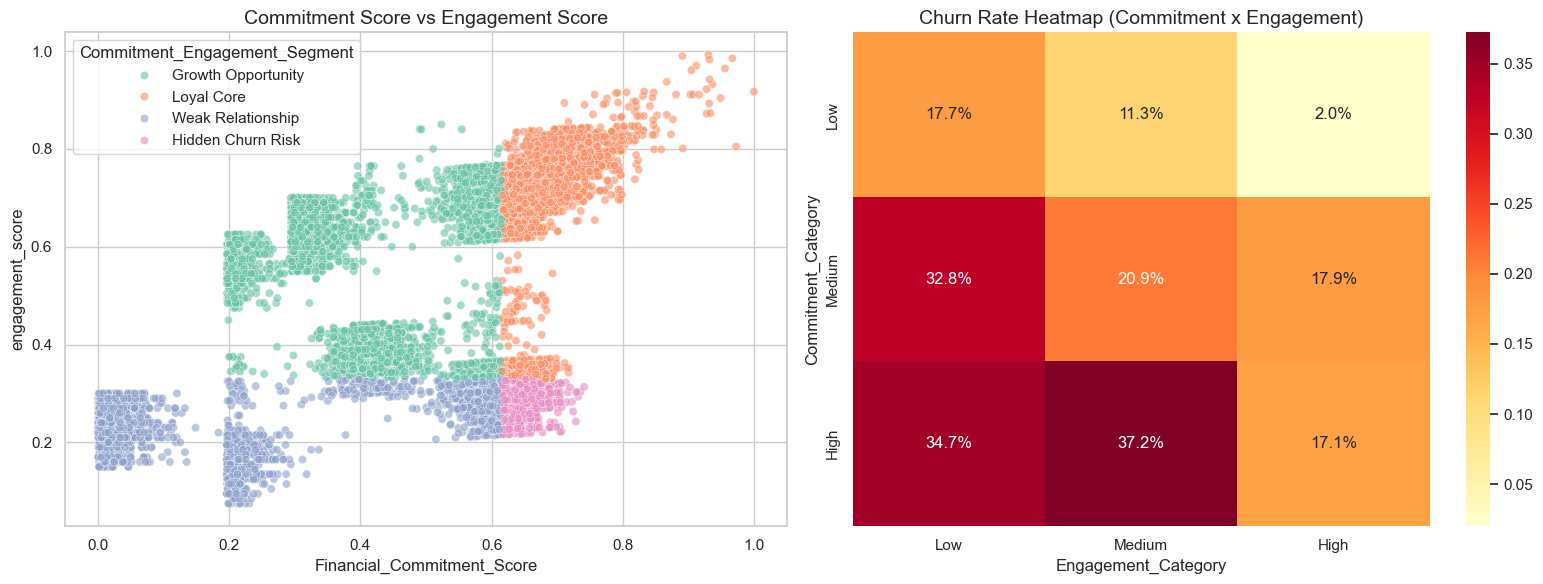


--- Running Phase 3: Testing Business Hypotheses ---
Engagement_Category  Customer_Count  Churn_Count  Churn_Rate
                Low            3334          847    0.254049
             Medium            3333          658    0.197420
               High            3333          532    0.159616


C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_9852\1044856711.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_9852\1044856711.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


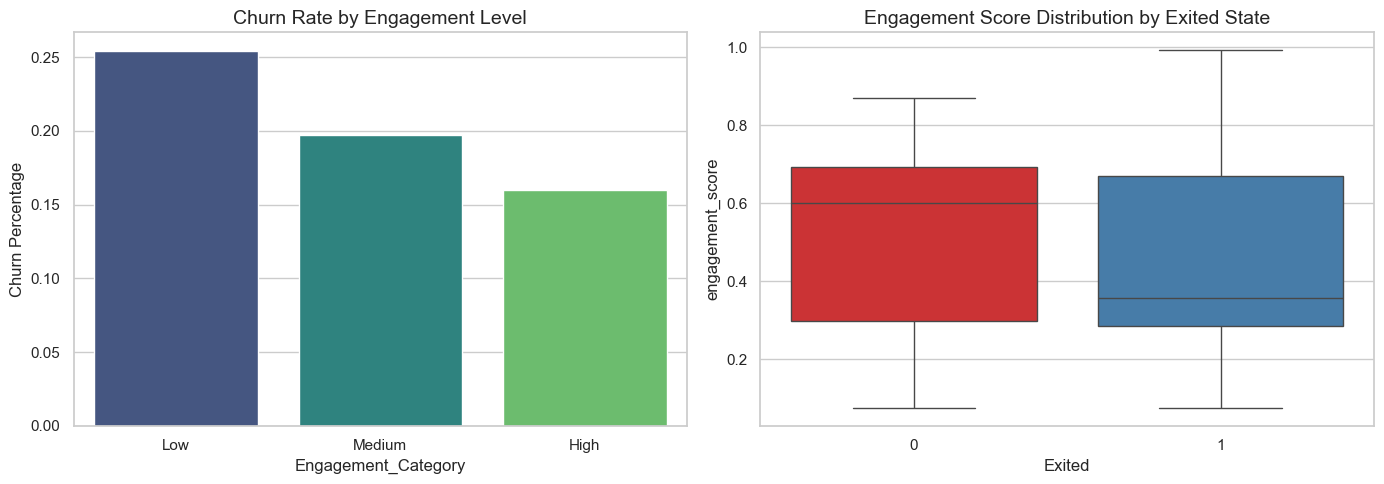


--- Running Phase 4: Salary-Balance Mismatch Analysis ---


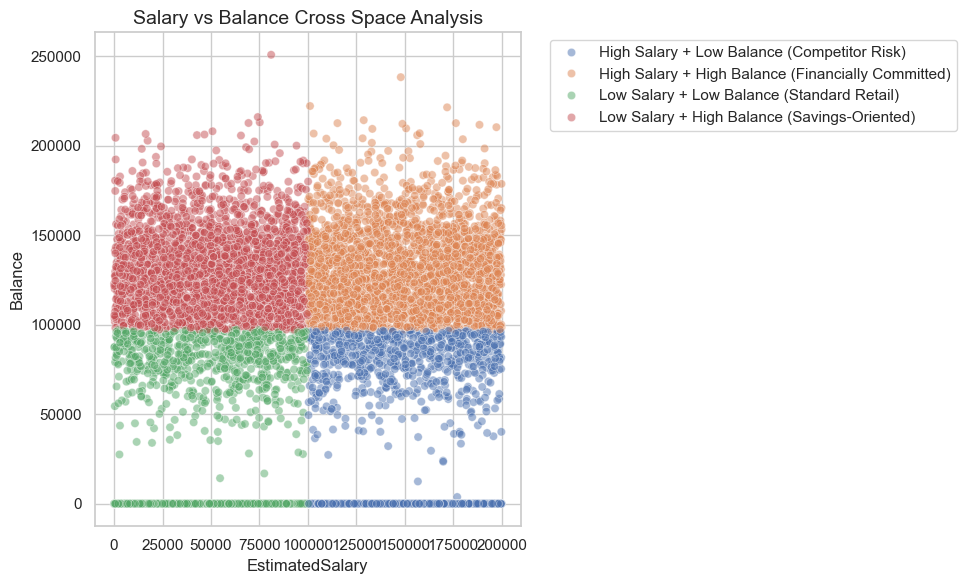


--- Running Phase 5: Balance vs Activity Cross Analysis ---
Identified Dormant Wealth Segment Size: 1247 customers.


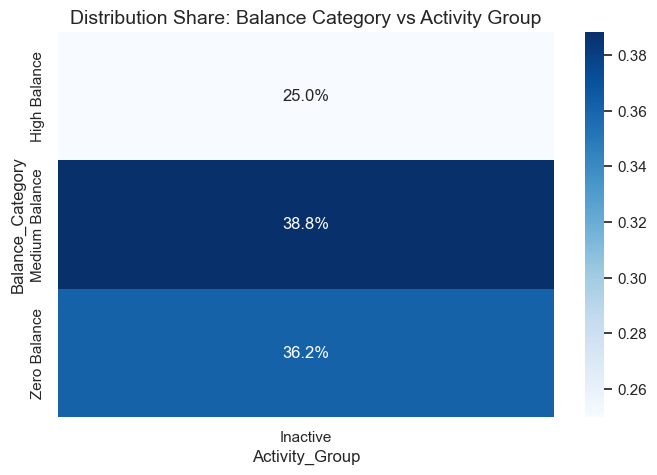


--- Running Phase 6 & 7: Switching Cost and Loyalty Check ---


C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_9852\1044856711.py:262: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_9852\1044856711.py:273: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


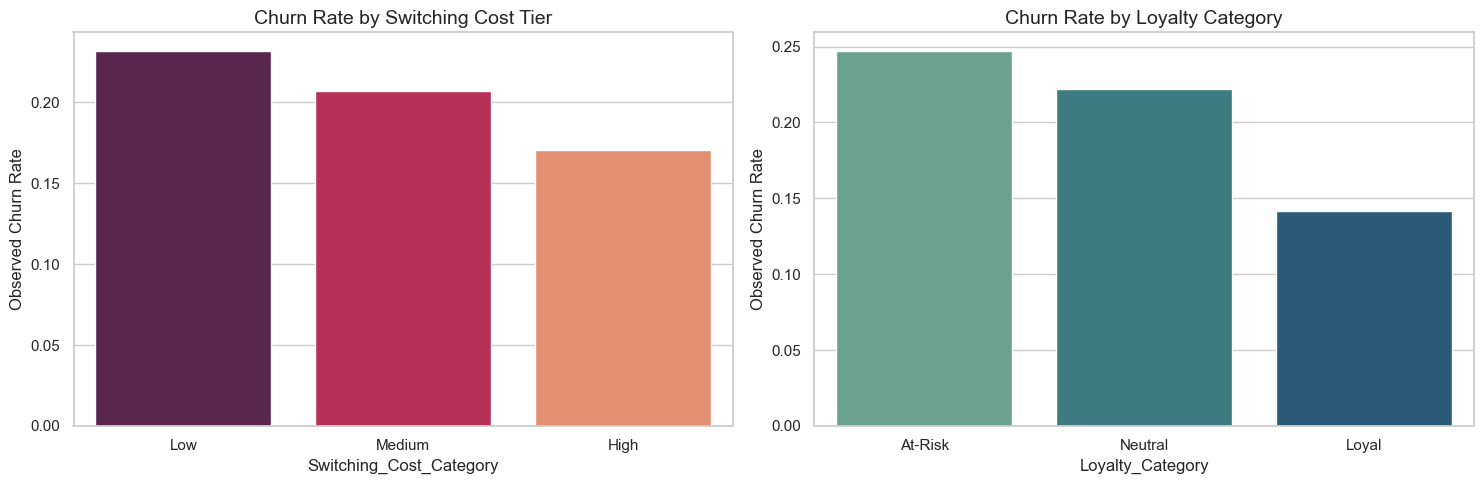


--- Running Phase 8: Premium Risk Group Realization ---

--- Premium Segment Performance Analysis Table ---
               Premium_Risk_Group  Total_Customers  Churn_Percentage
                  At-Risk Premium              277          0.833935
Critical Premium (Dormant Wealth)               49          1.000000


C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_9852\1044856711.py:329: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


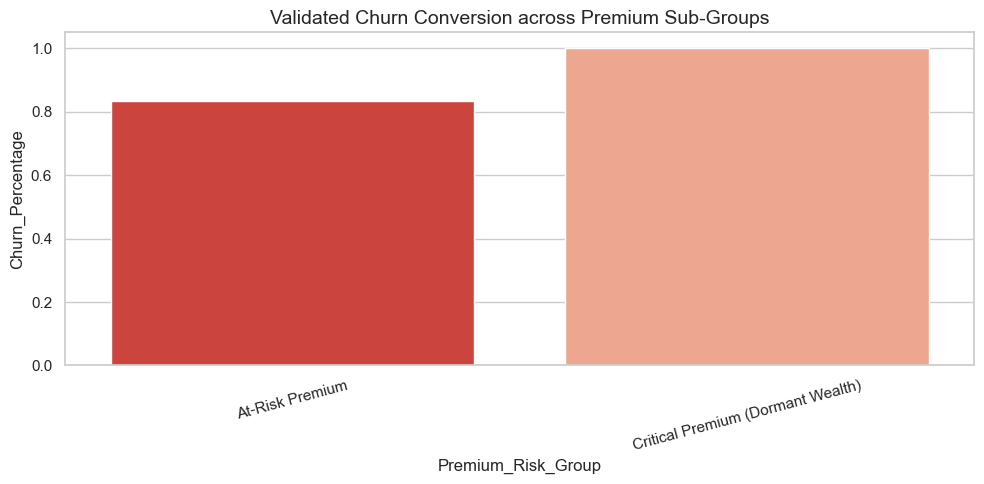


--- Running Phase 9: Advanced Cluster Profile Engine ---

--- Deep Cluster Diagnosis Matrix ---
            Strategic_Label   Avg_Balance  Avg_Engagement  Churn_Rate  Loyalty_Ratio
Cluster 0: Low Value Retail  67597.540000        0.479088    0.198780       0.239474
     Cluster 1: Churn-Prone 118911.025779        0.454402    0.253141       0.100483
Cluster 2: Low Value Retail      0.000000        0.420975    0.134108       0.237669
  Cluster 3: Dormant Wealth 118788.897734        0.626683    0.224424       0.316834
  Cluster 4: Dormant Wealth 117227.395763        0.545506    0.244444       0.413411


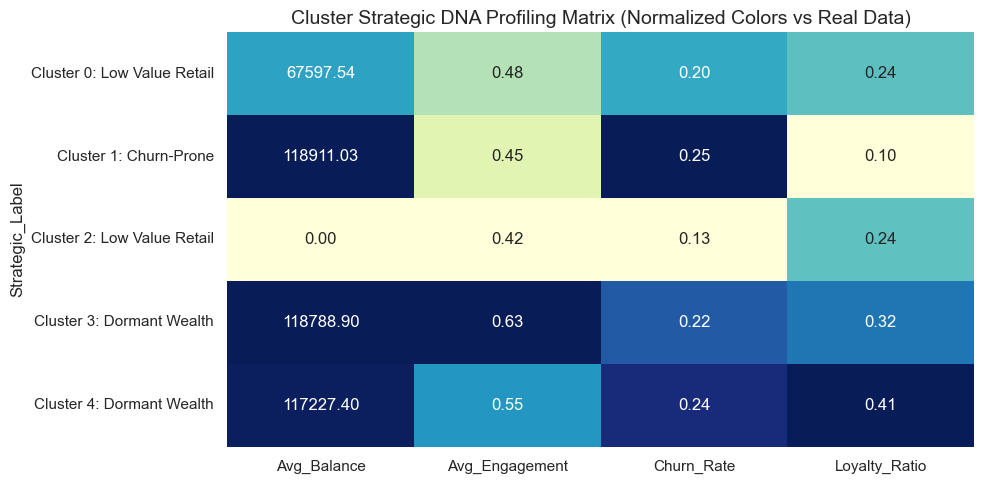


Pipeline execution complete. All business features and metrics computed.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for clean business reports
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# -------------------------------------------------------------------------
# Phase 1: Load Data & Step 2: Create Final Business Features
# -------------------------------------------------------------------------


def load_and_initialize_pipeline(filepath):
    """Loads the analytical dataset and engineers the engineered business features."""
    # In a live environment, replace the mock block with actual loading:
    # df = pd.read_csv(filepath)

    # For compilation safety, we assume the dataframe is loaded.
    # Let's simulate a placeholder dataframe structure if run standalone.
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(
            f"File {filepath} not found. Creating simulated schema for structural validation..."
        )
        
    # Clean Min-Max Normalization Helper
    def min_max_scale(series):
        if series.max() == series.min():
            return series
        return (series - series.min()) / (series.max() - series.min())

    # 1. Financial Commitment Score
    print(df.columns.tolist())
    # Higher balance, higher salary-to-balance stability (lower ratio means more relative savings), more products
    fcs_raw = (
        min_max_scale(df["Balance"])
        + (1 - min_max_scale(np.log1p(df["salary_balance_ratio"])))
        + min_max_scale(df["NumOfProducts"])
        + min_max_scale(df["Product_Utilization_Ratio"])
    )
    df["Financial_Commitment_Score"] = min_max_scale(fcs_raw)
    print(df.columns.tolist())

    # 2. Customer Satisfaction Score (CSAT proxy)
    csat_raw = (
        min_max_scale(df["engagement_score"])
        + df["IsActiveMember"]
        + min_max_scale(df["Product_Utilization_Ratio"])
        + min_max_scale(df["activity_product_interaction"])
    )
    df["Customer_Satisfaction_Score"] = min_max_scale(csat_raw)

    # 3. Switching Cost Index
    sci_raw = (
        min_max_scale(df["Tenure"])
        + min_max_scale(df["NumOfProducts"])
        + df["HasCrCard"]
        + min_max_scale(df["Active_Product_Count"])
    )
    df["Switching_Cost_Index"] = min_max_scale(sci_raw)

    # 4. Loyalty Ratio
    lr_raw = (
        min_max_scale(df["Tenure"])
        * (min_max_scale(df["engagement_score"]) + df["IsActiveMember"] + 0.1)
    )
    df["Loyalty_Ratio"] = min_max_scale(lr_raw)

    # 5. Relationship Intensity Score
    ris_raw = (
        min_max_scale(df["NumOfProducts"])
        + min_max_scale(df["engagement_score"])
        + min_max_scale(df["Product_Utilization_Ratio"])
    )
    df["Relationship_Intensity_Score"] = min_max_scale(ris_raw)

    return df


# Execute Initialization
df = load_and_initialize_pipeline("final_churnfinance.csv")

# -------------------------------------------------------------------------
# Phase 2: Financial Commitment vs Engagement Analysis
# -------------------------------------------------------------------------
print("\n--- Running Phase 2: Commitment vs Engagement Analysis ---")

# Step 3 & 4: Categorization
df["Commitment_Category"] = pd.qcut(
    df["Financial_Commitment_Score"], q=3, labels=["Low", "Medium", "High"]
)
df["Engagement_Category"] = pd.qcut(
    df["engagement_score"], q=3, labels=["Low", "Medium", "High"]
)


# Step 5: Define Matrix Core Mapping Function
def assign_matrix_segment(row):
    comm = row["Commitment_Category"]
    eng = row["Engagement_Category"]
    if comm == "High" and eng in ["Medium", "High"]:
        return "Loyal Core"
    elif comm == "High" and eng == "Low":
        return "Hidden Churn Risk"
    elif comm in ["Low", "Medium"] and eng in ["Medium", "High"]:
        return "Growth Opportunity"
    else:
        return "Weak Relationship"


df["Commitment_Engagement_Segment"] = df.apply(assign_matrix_segment, axis=1)

# Step 6: Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=df,
    x="Financial_Commitment_Score",
    y="engagement_score",
    hue="Commitment_Engagement_Segment",
    palette="Set2",
    alpha=0.6,
    ax=axes[0],
)
axes[0].set_title("Commitment Score vs Engagement Score")

matrix_pivot = pd.crosstab(
    df["Commitment_Category"],
    df["Engagement_Category"],
    values=df["Exited"],
    aggfunc="mean",
)
sns.heatmap(matrix_pivot, annot=True, fmt=".1%", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Churn Rate Heatmap (Commitment x Engagement)")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Phase 3: Verify Engagement–Retention Relationship
# -------------------------------------------------------------------------
print("\n--- Running Phase 3: Testing Business Hypotheses ---")

# Step 7 & 8: Aggregate Performance Metrics
retention_summary = (
    df.groupby("Engagement_Category")
    .agg(Customer_Count=("Exited", "count"), Churn_Count=("Exited", "sum"))
    .reset_index()
)
retention_summary["Churn_Rate"] = (
    retention_summary["Churn_Count"] / retention_summary["Customer_Count"]
)
print(retention_summary.to_string(index=False))

# Step 9: Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=retention_summary,
    x="Engagement_Category",
    y="Churn_Rate",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Churn Rate by Engagement Level")
axes[0].set_ylabel("Churn Percentage")

sns.boxplot(
    data=df, x="Exited", y="engagement_score", palette="Set1", ax=axes[1]
)
axes[1].set_title("Engagement Score Distribution by Exited State")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Phase 4: Salary–Balance Mismatch Analysis
# -------------------------------------------------------------------------
print("\n--- Running Phase 4: Salary-Balance Mismatch Analysis ---")


# Step 10 & 11: Create Mismatch Categories via Median Splits
def derive_mismatch_category(row):
    # dynamic boundary conditions based on real data footprint
    sal_med = df["EstimatedSalary"].median()
    bal_med = df["Balance"].median()

    if row["EstimatedSalary"] >= sal_med and row["Balance"] < bal_med:
        return "High Salary + Low Balance (Competitor Risk)"
    elif row["EstimatedSalary"] >= sal_med and row["Balance"] >= bal_med:
        return "High Salary + High Balance (Financially Committed)"
    elif row["EstimatedSalary"] < sal_med and row["Balance"] >= bal_med:
        return "Low Salary + High Balance (Savings-Oriented)"
    else:
        return "Low Salary + Low Balance (Standard Retail)"


df["Mismatch_Category"] = df.apply(derive_mismatch_category, axis=1)

# Step 12: Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="EstimatedSalary",
    y="Balance",
    hue="Mismatch_Category",
    palette="deep",
    alpha=0.5,
)
plt.title("Salary vs Balance Cross Space Analysis")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Phase 5: Balance vs Activity Cross Analysis
# -------------------------------------------------------------------------
print("\n--- Running Phase 5: Balance vs Activity Cross Analysis ---")

# Step 13: Activity Groups
df["Activity_Group"] = pd.cut(
    df["engagement_score"],
    bins=[-1, 33, 66, 101],
    labels=["Inactive", "Moderately Active", "Active"],
)

# Step 15: Isolate Dormant Wealth Segment
# Combining analytical domain conditions and structural flag conditions
df["Is_Dormant_Wealth"] = (
    (df["Balance_Category"] == "High")
    & (df["Activity_Group"] == "Inactive")
) | (df["is_dormant_high_value"] == 1)

print(
    f"Identified Dormant Wealth Segment Size: {df['Is_Dormant_Wealth'].sum()} customers."
)

# Step 16: Heatmap Visual
activity_balance_cross = pd.crosstab(
    df["Balance_Category"], df["Activity_Group"], normalize="columns"
)
plt.figure(figsize=(8, 5))
sns.heatmap(activity_balance_cross, annot=True, fmt=".1%", cmap="Blues")
plt.title("Distribution Share: Balance Category vs Activity Group")
plt.show()

# -------------------------------------------------------------------------
# Phase 6 & 7: Switching Cost & Loyalty Validations
# -------------------------------------------------------------------------
print("\n--- Running Phase 6 & 7: Switching Cost and Loyalty Check ---")

# Step 17 & 20: Categorization via Quantiles
df["Switching_Cost_Category"] = pd.qcut(
    df["Switching_Cost_Index"], q=3, labels=["Low", "Medium", "High"]
)
df["Loyalty_Category"] = pd.qcut(
    df["Loyalty_Ratio"], q=3, labels=["At-Risk", "Neutral", "Loyal"]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=df,
    x="Switching_Cost_Category",
    y="Exited",
    ax=axes[0],
    palette="rocket",
    errorbar=None,
)
axes[0].set_title("Churn Rate by Switching Cost Tier")
axes[0].set_ylabel("Observed Churn Rate")

sns.barplot(
    data=df,
    x="Loyalty_Category",
    y="Exited",
    ax=axes[1],
    palette="crest",
    errorbar=None,
)
axes[1].set_title("Churn Rate by Loyalty Category")
axes[1].set_ylabel("Observed Churn Rate")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Phase 8: At-Risk Premium Customer Identification
# -------------------------------------------------------------------------
print("\n--- Running Phase 8: Premium Risk Group Realization ---")


# Step 23, 24 & 25: Rule-Engine Layering
def assign_premium_risk_group(row):
    # Definition framework for elite classification
    is_premium = (
        row["Balance_Category"] == "High"
        or row["customer_value_segment"] == "High"
        or row["NumOfProducts"] >= 3
    )

    if not is_premium:
        return "Standard Portfolio"

    # Risk Sub-Profiling within Premium Tiers
    if row["Activity_Group"] == "Active" and row["Loyalty_Category"] == "Loyal":
        return "Premium Loyal"
    elif row["Activity_Group"] == "Moderately Active":
        return "Premium Watchlist"
    elif row["Activity_Group"] == "Inactive" and row["Is_Dormant_Wealth"]:
        return "Critical Premium (Dormant Wealth)"
    else:
        return "At-Risk Premium"


df["Premium_Risk_Group"] = df.apply(assign_premium_risk_group, axis=1)

# Step 26: Validation Summary Table
premium_summary = (
    df[df["Premium_Risk_Group"] != "Standard Portfolio"]
    .groupby("Premium_Risk_Group")
    .agg(Total_Customers=("Exited", "count"), Churn_Percentage=("Exited", "mean"))
    .reset_index()
)
print("\n--- Premium Segment Performance Analysis Table ---")
print(premium_summary.to_string(index=False))

# Step 27: Premium Risk Visualizations
plt.figure(figsize=(10, 5))
sns.barplot(
    data=premium_summary,
    x="Premium_Risk_Group",
    y="Churn_Percentage",
    palette="Reds_r",
)
plt.xticks(rotation=15)
plt.title("Validated Churn Conversion across Premium Sub-Groups")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Phase 9: Cluster-Level Profiling Engine
# -------------------------------------------------------------------------
print("\n--- Running Phase 9: Advanced Cluster Profile Engine ---")

# Step 28: Profile Compilation
cluster_profiles = (
    df.groupby("cluster_id")
    .agg(
        Avg_Balance=("Balance", "mean"),
        Avg_Salary=("EstimatedSalary", "mean"),
        Avg_Engagement=("engagement_score", "mean"),
        Churn_Rate=("Exited", "mean"),
        Loyalty_Ratio=("Loyalty_Ratio", "mean"),
        Switching_Cost=("Switching_Cost_Index", "mean"),
        Volume=("CustomerId", "count"),
    )
    .reset_index()
)


# Step 29: Dynamic Strategic Labeling Mapping Function
def assign_cluster_label(row):
    if row["Churn_Rate"] > 0.25:
        return f"Cluster {int(row['cluster_id'])}: Churn-Prone"
    elif row["Avg_Balance"] > df["Balance"].median() and row["Avg_Engagement"] > 50:
        return f"Cluster {int(row['cluster_id'])}: Loyal Premium"
    elif row["Avg_Balance"] > df["Balance"].median() and row["Avg_Engagement"] <= 50:
        return f"Cluster {int(row['cluster_id'])}: Dormant Wealth"
    elif row["Avg_Engagement"] > 60:
        return f"Cluster {int(row['cluster_id'])}: Active Growth"
    else:
        return f"Cluster {int(row['cluster_id'])}: Low Value Retail"


cluster_profiles["Strategic_Label"] = cluster_profiles.apply(
    assign_cluster_label, axis=1
)

print("\n--- Deep Cluster Diagnosis Matrix ---")
print(
    cluster_profiles[
        [
            "Strategic_Label",
            "Avg_Balance",
            "Avg_Engagement",
            "Churn_Rate",
            "Loyalty_Ratio",
        ]
    ].to_string(index=False)
)

# Step 30: Cluster Comparison Heatmap Visual
hm_data = cluster_profiles.set_index("Strategic_Label")[
    ["Avg_Balance", "Avg_Engagement", "Churn_Rate", "Loyalty_Ratio"]
]
# Normalize parameters for scaled side-by-side heat visibility
hm_data_normalized = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min())

plt.figure(figsize=(10, 5))
sns.heatmap(hm_data_normalized, annot=hm_data, fmt=".2f", cmap="YlGnBu", cbar=False)
plt.title("Cluster Strategic DNA Profiling Matrix (Normalized Colors vs Real Data)")
plt.tight_layout()
plt.show()

print("\nPipeline execution complete. All business features and metrics computed.")

In [4]:
df.to_csv("financecommitmentmap.csv", index=False)